In [1]:
#the pip commands to be used here

%pip install requests
%pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [2]:
#the import packages
import requests
import pandas as pd
from pandas import json_normalize
import requests
import os
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#some constants to be used
base_url = "http://192.168.43.25:8080/dataAnalysisEndpoints/"
def create_url(endpoint):
    return base_url + endpoint
def getData(url):
    response = requests.get(url)

    # Check response status
    if response.status_code == 200:
        data = response.json()
        print(f"Received {len(data)} records.")
        return data
    else:
        print(f"Error: {response.status_code}")

In [4]:
#get the user Input data
# Send request
url = create_url('getAllUserInputsExperimentState')
df_userInputData = pd.DataFrame.from_dict(getData(url))


Received 35 records.


In [5]:
details_df = df_userInputData["details"].apply(pd.Series)

# Then join with the original DataFrame (drop the nested 'details' if desired)
df_userInputData = pd.concat([df_userInputData.drop(columns=["details"]), details_df], axis=1)

In [6]:
df_userInputData

,_id,experimentState,timestamp,userInputCategory,0,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,pollutant-type,quantity-used,room,side-right-wall
0,{'$oid': '6849ace703a598ff63a65bf8'},StartingExperiment,{'$date': 1749658855857},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,{'$oid': '6849aefb03a598ff63a6667f'},InsertingSourcePollutant,{'$date': 1749659387774},ExperimentState,NaN,on,on,on,1.5,φαρμακευτική λοτιόν,,VOC,δύο κουταλιές της σούπας,Σαλόνι,1.7
2,{'$oid': '6849b77503a598ff63a68c90'},RemovingSourcePollutant,{'$date': 1749661557509},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,{'$oid': '6849ba8d03a598ff63a69cd3'},InsertingSourcePollutant,{'$date': 1749662349567},ExperimentState,NaN,on,on,on,1.5,Φαρμακευτικό αλκοόλ,,VOC,τρεις κουταλιά της σούπας,Σαλόνι,1.7
4,{'$oid': '6849c2dc03a598ff63a6c299'},RemovingSourcePollutant,{'$date': 1749664476491},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,{'$oid': '6849c5ab03a598ff63a6ce5f'},InsertingSourcePollutant,{'$date': 1749665195504},ExperimentState,NaN,on,on,on,1.5,Φαρμακευτικό αλκοόλ,,VOC,τρεις κουταλιά της σούπας,Σαλόνι,1.7
6,{'$oid': '6849cdc303a598ff63a6f7a7'},RemovingSourcePollutant,{'$date': 1749667267330},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,{'$oid': '6849d10203a598ff63a7085e'},InsertingSourcePollutant,{'$date': 1749668098365},ExperimentState,NaN,on,on,on,1.5,Φαρμακευτικό αλκοόλ,,VOC,τρεις κουταλιά της σούπας,Σαλόνι,1.7
8,{'$oid': '6849d99703a598ff63a73445'},RemovingSourcePollutant,{'$date': 1749670295490},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,{'$oid': '6849ddff03a598ff63a74a63'},InsertingSourcePollutant,{'$date': 1749671423708},ExperimentState,NaN,on,NaN,on,1.5,Φαρμακευτικό αλκοόλ,,VOC,τρεις κουταλιά της σούπας,Σαλόνι,1.7


In [7]:
df_userInputData = df_userInputData.drop(columns=['0'])

KeyError: "['0'] not found in axis"

In [18]:
# Convert epoch (assumes seconds) to datetime in local time
df_userInputData["epoch_ms"] = df_userInputData["timestamp"].apply(lambda x: x["$date"])
df_userInputData["timestamp_local"] = pd.to_datetime(df_userInputData["epoch_ms"], unit="ms").dt.tz_localize("UTC").dt.tz_convert("Europe/Athens")
df_userInputData.drop(columns = ["timestamp"])

,_id,experimentState,userInputCategory,0,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,pollutant-type,quantity-used,room,side-right-wall,epoch_ms,timestamp_local
0,{'$oid': '6849ace703a598ff63a65bf8'},StartingExperiment,ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1749658855857,2025-06-11 19:20:55.857000+03:00
1,{'$oid': '6849aefb03a598ff63a6667f'},InsertingSourcePollutant,ExperimentState,NaN,on,on,on,1.5,φαρμακευτική λοτιόν,,VOC,δύο κουταλιές της σούπας,Σαλόνι,1.7,1749659387774,2025-06-11 19:29:47.774000+03:00
2,{'$oid': '6849b77503a598ff63a68c90'},RemovingSourcePollutant,ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1749661557509,2025-06-11 20:05:57.509000+03:00
3,{'$oid': '6849ba8d03a598ff63a69cd3'},InsertingSourcePollutant,ExperimentState,NaN,on,on,on,1.5,Φαρμακευτικό αλκοόλ,,VOC,τρεις κουταλιά της σούπας,Σαλόνι,1.7,1749662349567,2025-06-11 20:19:09.567000+03:00
4,{'$oid': '6849c2dc03a598ff63a6c299'},RemovingSourcePollutant,ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1749664476491,2025-06-11 20:54:36.491000+03:00
5,{'$oid': '6849c5ab03a598ff63a6ce5f'},InsertingSourcePollutant,ExperimentState,NaN,on,on,on,1.5,Φαρμακευτικό αλκοόλ,,VOC,τρεις κουταλιά της σούπας,Σαλόνι,1.7,1749665195504,2025-06-11 21:06:35.504000+03:00
6,{'$oid': '6849cdc303a598ff63a6f7a7'},RemovingSourcePollutant,ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1749667267330,2025-06-11 21:41:07.330000+03:00
7,{'$oid': '6849d10203a598ff63a7085e'},InsertingSourcePollutant,ExperimentState,NaN,on,on,on,1.5,Φαρμακευτικό αλκοόλ,,VOC,τρεις κουταλιά της σούπας,Σαλόνι,1.7,1749668098365,2025-06-11 21:54:58.365000+03:00
8,{'$oid': '6849d99703a598ff63a73445'},RemovingSourcePollutant,ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1749670295490,2025-06-11 22:31:35.490000+03:00
9,{'$oid': '6849ddff03a598ff63a74a63'},InsertingSourcePollutant,ExperimentState,NaN,on,NaN,on,1.5,Φαρμακευτικό αλκοόλ,,VOC,τρεις κουταλιά της σούπας,Σαλόνι,1.7,1749671423708,2025-06-11 22:50:23.708000+03:00


In [9]:
start_time = df_userInputData.loc[18,"epoch_ms"]
end_time   = df_userInputData.loc[30,"epoch_ms"] 

url = "http://192.168.43.25:8080/timeSeriesEndpoints/getTimeSeriesData?start=" + str(start_time) + '&end=' +str(end_time)
print(url)
df_timeSeriesDuringExperiments = pd.DataFrame.from_dict(getData(url))

http://192.168.43.25:8080/timeSeriesEndpoints/getTimeSeriesData?start=1749743543693&end=1749767842431
Received 33675 records.


In [10]:
df_timeSeriesDuringExperiments

,BME680:breathVocEquivalent,BME680:co2Equivalent,BME680:gasPercentage,BME680:gasResistance,BME680:humidity,BME680:iaq,BME680:iaqAccuracy,BME680:staticIaq,BME680:temperature,Id,Sensor,_id,timestamp,CCS811:30minutesPassed,CCS811:RawResistance,CCS811:TVOC,CCS811:eCO2
0,0.521010,607.2610,3.139026,202444.30,49.36712,50.93520,3.0,51.81526,30.39953,2,BME680,{'$oid': '684af7b88ad2cd52978f4b01'},2025-06-12T15:52:24.302Z,NaN,NaN,NaN,NaN
1,0.509392,603.2829,4.195984,73519.62,47.82921,51.02390,3.0,50.82072,30.18756,1,BME680,{'$oid': '684af7ba8ad2cd52978f4b04'},2025-06-12T15:52:26.306Z,NaN,NaN,NaN,NaN
2,0.526043,608.9572,3.180622,200827.40,49.44656,51.15368,3.0,52.23928,30.38933,2,BME680,{'$oid': '684af7bb8ad2cd52978f4b07'},2025-06-12T15:52:27.326Z,NaN,NaN,NaN,NaN
3,0.510723,603.7435,4.226869,73519.62,47.81642,51.16758,3.0,50.93586,30.18756,1,BME680,{'$oid': '684af7bd8ad2cd52978f4b0a'},2025-06-12T15:52:29.865Z,NaN,NaN,NaN,NaN
4,0.525779,608.8685,3.178450,201446.30,49.44389,51.14231,3.0,52.21714,30.39188,2,BME680,{'$oid': '684af7be8ad2cd52978f4b0d'},2025-06-12T15:52:30.604Z,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33670,1.190076,882.4377,7.141284,177617.50,64.45795,74.31653,3.0,88.24377,25.74519,2,BME680,{'$oid': '684b569fb6e12fa45686188d'},2025-06-12T22:37:19.775Z,NaN,NaN,NaN,NaN
33671,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,CCS811,{'$oid': '684b569fb6e12fa456861890'},2025-06-12T22:37:19.962Z,1.0,535.0,5557.0,4272.0
33672,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,CCS811,{'$oid': '684b56a1b6e12fa456861893'},2025-06-12T22:37:21.595Z,1.0,538.0,5513.0,4248.0
33673,0.659822,648.9291,5.420489,70156.30,59.56725,67.29487,3.0,62.23227,26.90834,1,BME680,{'$oid': '684b56a1b6e12fa456861896'},2025-06-12T22:37:21.720Z,NaN,NaN,NaN,NaN


In [11]:
# 1. Select only the needed columns
df_timeSeriesDuringExperiments_copy = df_timeSeriesDuringExperiments[['timestamp', 'Id', 'BME680:breathVocEquivalent', 'CCS811:TVOC']].copy()

# 2. Convert `timestamp` (UTC) to Europe/Athens tz-aware datetime
df_timeSeriesDuringExperiments_copy['timestamp'] = (
    pd.to_datetime(df_timeSeriesDuringExperiments_copy['timestamp'], utc=True)
      .dt.tz_convert('Europe/Athens')
)
# 3. Create the three “Id=…:” columns
df_timeSeriesDuringExperiments_copy['Id=0:CCS811:TVOC'] = np.where(
    df_timeSeriesDuringExperiments_copy['Id'] == 0, df_timeSeriesDuringExperiments_copy['CCS811:TVOC'], np.nan
)
df_timeSeriesDuringExperiments_copy['Id=1:BME680:breathVocEquivalent'] = np.where(
    df_timeSeriesDuringExperiments_copy['Id'] == 1, df_timeSeriesDuringExperiments_copy['BME680:breathVocEquivalent'], np.nan
)
df_timeSeriesDuringExperiments_copy['Id=2:BME680:breathVocEquivalent'] = np.where(
    df_timeSeriesDuringExperiments_copy['Id'] == 2, df_timeSeriesDuringExperiments_copy['BME680:breathVocEquivalent'], np.nan
)

# 4. Set timestamp as the row index
df_timeSeriesDuringExperiments_copy.set_index('timestamp', inplace=True)

# 5. Drop the old Id+raw measurement columns
df_timeSeriesDuringExperiments_final = df_timeSeriesDuringExperiments_copy.drop(
    columns=['Id', 'BME680:breathVocEquivalent', 'CCS811:TVOC']
)

# Inspect result
df_timeSeriesDuringExperiments_final.head()
df_timeSeriesDuringExperiments_final

,Id=0:CCS811:TVOC,Id=1:BME680:breathVocEquivalent,Id=2:BME680:breathVocEquivalent
timestamp,,,
2025-06-12 18:52:24.302000+03:00,NaN,NaN,0.521010
2025-06-12 18:52:26.306000+03:00,NaN,0.509392,NaN
2025-06-12 18:52:27.326000+03:00,NaN,NaN,0.526043
2025-06-12 18:52:29.865000+03:00,NaN,0.510723,NaN
2025-06-12 18:52:30.604000+03:00,NaN,NaN,0.525779
...,...,...,...
2025-06-13 01:37:19.775000+03:00,NaN,NaN,1.190076
2025-06-13 01:37:19.962000+03:00,5557.0,NaN,NaN
2025-06-13 01:37:21.595000+03:00,5513.0,NaN,NaN


In [12]:
df_timeSeriesDuringExperiments_final

,Id=0:CCS811:TVOC,Id=1:BME680:breathVocEquivalent,Id=2:BME680:breathVocEquivalent
timestamp,,,
2025-06-12 18:52:24.302000+03:00,NaN,NaN,0.521010
2025-06-12 18:52:26.306000+03:00,NaN,0.509392,NaN
2025-06-12 18:52:27.326000+03:00,NaN,NaN,0.526043
2025-06-12 18:52:29.865000+03:00,NaN,0.510723,NaN
2025-06-12 18:52:30.604000+03:00,NaN,NaN,0.525779
...,...,...,...
2025-06-13 01:37:19.775000+03:00,NaN,NaN,1.190076
2025-06-13 01:37:19.962000+03:00,5557.0,NaN,NaN
2025-06-13 01:37:21.595000+03:00,5513.0,NaN,NaN


In [19]:
# 1. Filter only rows 18 to 30 from df_userInputData
df_events = df_userInputData.iloc[19:30].reset_index(drop=True)
df_events


,_id,experimentState,timestamp,userInputCategory,0,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,pollutant-type,quantity-used,room,side-right-wall,epoch_ms,timestamp_local
0,{'$oid': '684afcdf8ad2cd52978f638d'},InsertingSourcePollutant,{'$date': 1749744863788},ExperimentState,NaN,on,on,on,1.5,Φαρμακευτικό αλκοόλ 95%,,VOC,μία κουταλιά της σούπας,Σαλόνι,1.5,1749744863788,2025-06-12 19:14:23.788000+03:00
1,{'$oid': '684b0c908ad2cd52978f8641'},RemovingSourcePollutant,{'$date': 1749748880682},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1749748880682,2025-06-12 20:21:20.682000+03:00
2,{'$oid': '684b12168ad2cd52978f92ea'},InsertingSourcePollutant,{'$date': 1749750294045},ExperimentState,NaN,on,on,on,1.5,Φαρμακευτικό αλκοόλ 95%,,VOC,13 ml περιπου,σαλονι,1.5,1749750294045,2025-06-12 20:44:54.045000+03:00
3,{'$oid': '684b1be48ad2cd52978fc054'},RemovingSourcePollutant,{'$date': 1749752804880},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1749752804880,2025-06-12 21:26:44.880000+03:00
4,{'$oid': '684b21cb8ad2cd52978fdeca'},InsertingSourcePollutant,{'$date': 1749754315351},ExperimentState,NaN,on,on,on,1.5,Φαρμακευτικό αλκοόλ 95%,,VOC,17 ml,Σαλόνι,1.7,1749754315351,2025-06-12 21:51:55.351000+03:00
5,{'$oid': '684b2af0c4ba872d6a031472'},RemovingSourcePollutant,{'$date': 1749756656094},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1749756656094,2025-06-12 22:30:56.094000+03:00
6,{'$oid': '684b3582440322b264da457e'},InsertingSourcePollutant,{'$date': 1749759362051},ExperimentState,NaN,on,on,on,1.5,Φαρμακευτικό αλκοόλ 95%,,VOC,10 ml,Σαλόνι,1.7,1749759362051,2025-06-12 23:16:02.051000+03:00
7,{'$oid': '684b3ebc99afe3f757053c92'},RemovingSourcePollutant,{'$date': 1749761724467},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1749761724467,2025-06-12 23:55:24.467000+03:00
8,{'$oid': '684b4244c3e31ce70438ae27'},InsertingSourcePollutant,{'$date': 1749762628817},ExperimentState,NaN,on,on,on,1.5,Φαρμακευτικό αλκοόλ 95%,,VOC,13,Σαλόνι,1.7,1749762628817,2025-06-13 00:10:28.817000+03:00
9,{'$oid': '684b4b79b6e12fa45685e02c'},RemovingSourcePollutant,{'$date': 1749764985584},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1749764985584,2025-06-13 00:49:45.584000+03:00


In [22]:
# 2. Identify experiment periods based on Inserting/RemovingSourcePollutant
experiment_periods = []
for i in range(0, len(df_events) - 1, 2):
    start_row = df_events.iloc[i]
    end_row = df_events.iloc[i + 1]
    
    if (start_row['experimentState'] == 'InsertingSourcePollutant' and
        end_row['experimentState'] == 'RemovingSourcePollutant'):

        start_time = pd.to_datetime(start_row['timestamp_local'])
        end_time = pd.to_datetime(end_row['timestamp_local'])
        experiment_periods.append((start_time, end_time))

# 3. Create plots using Seaborn
num_experiments = len(experiment_periods)
print (experiment_periods)


[(Timestamp('2025-06-12 19:14:23.788000+0300', tz='Europe/Athens'), Timestamp('2025-06-12 20:21:20.682000+0300', tz='Europe/Athens')), (Timestamp('2025-06-12 20:44:54.045000+0300', tz='Europe/Athens'), Timestamp('2025-06-12 21:26:44.880000+0300', tz='Europe/Athens')), (Timestamp('2025-06-12 21:51:55.351000+0300', tz='Europe/Athens'), Timestamp('2025-06-12 22:30:56.094000+0300', tz='Europe/Athens')), (Timestamp('2025-06-12 23:16:02.051000+0300', tz='Europe/Athens'), Timestamp('2025-06-12 23:55:24.467000+0300', tz='Europe/Athens')), (Timestamp('2025-06-13 00:10:28.817000+0300', tz='Europe/Athens'), Timestamp('2025-06-13 00:49:45.584000+0300', tz='Europe/Athens'))]


In [23]:
# Ensure the index is sorted and timezone-aware
df_timeSeriesDuringExperiments_final = df_timeSeriesDuringExperiments_final.sort_index()

# Find the actual bounds in the timeseries data for the experiment window
actual_start_time = df_timeSeriesDuringExperiments_final.index[
    df_timeSeriesDuringExperiments_final.index.searchsorted(start_time, side="left")
]

actual_end_time = df_timeSeriesDuringExperiments_final.index[
    df_timeSeriesDuringExperiments_final.index.searchsorted(end_time, side="right") - 1
]

# Slice the time series data between the actual bounds
df_period_data = df_timeSeriesDuringExperiments_final.loc[actual_start_time:actual_end_time]

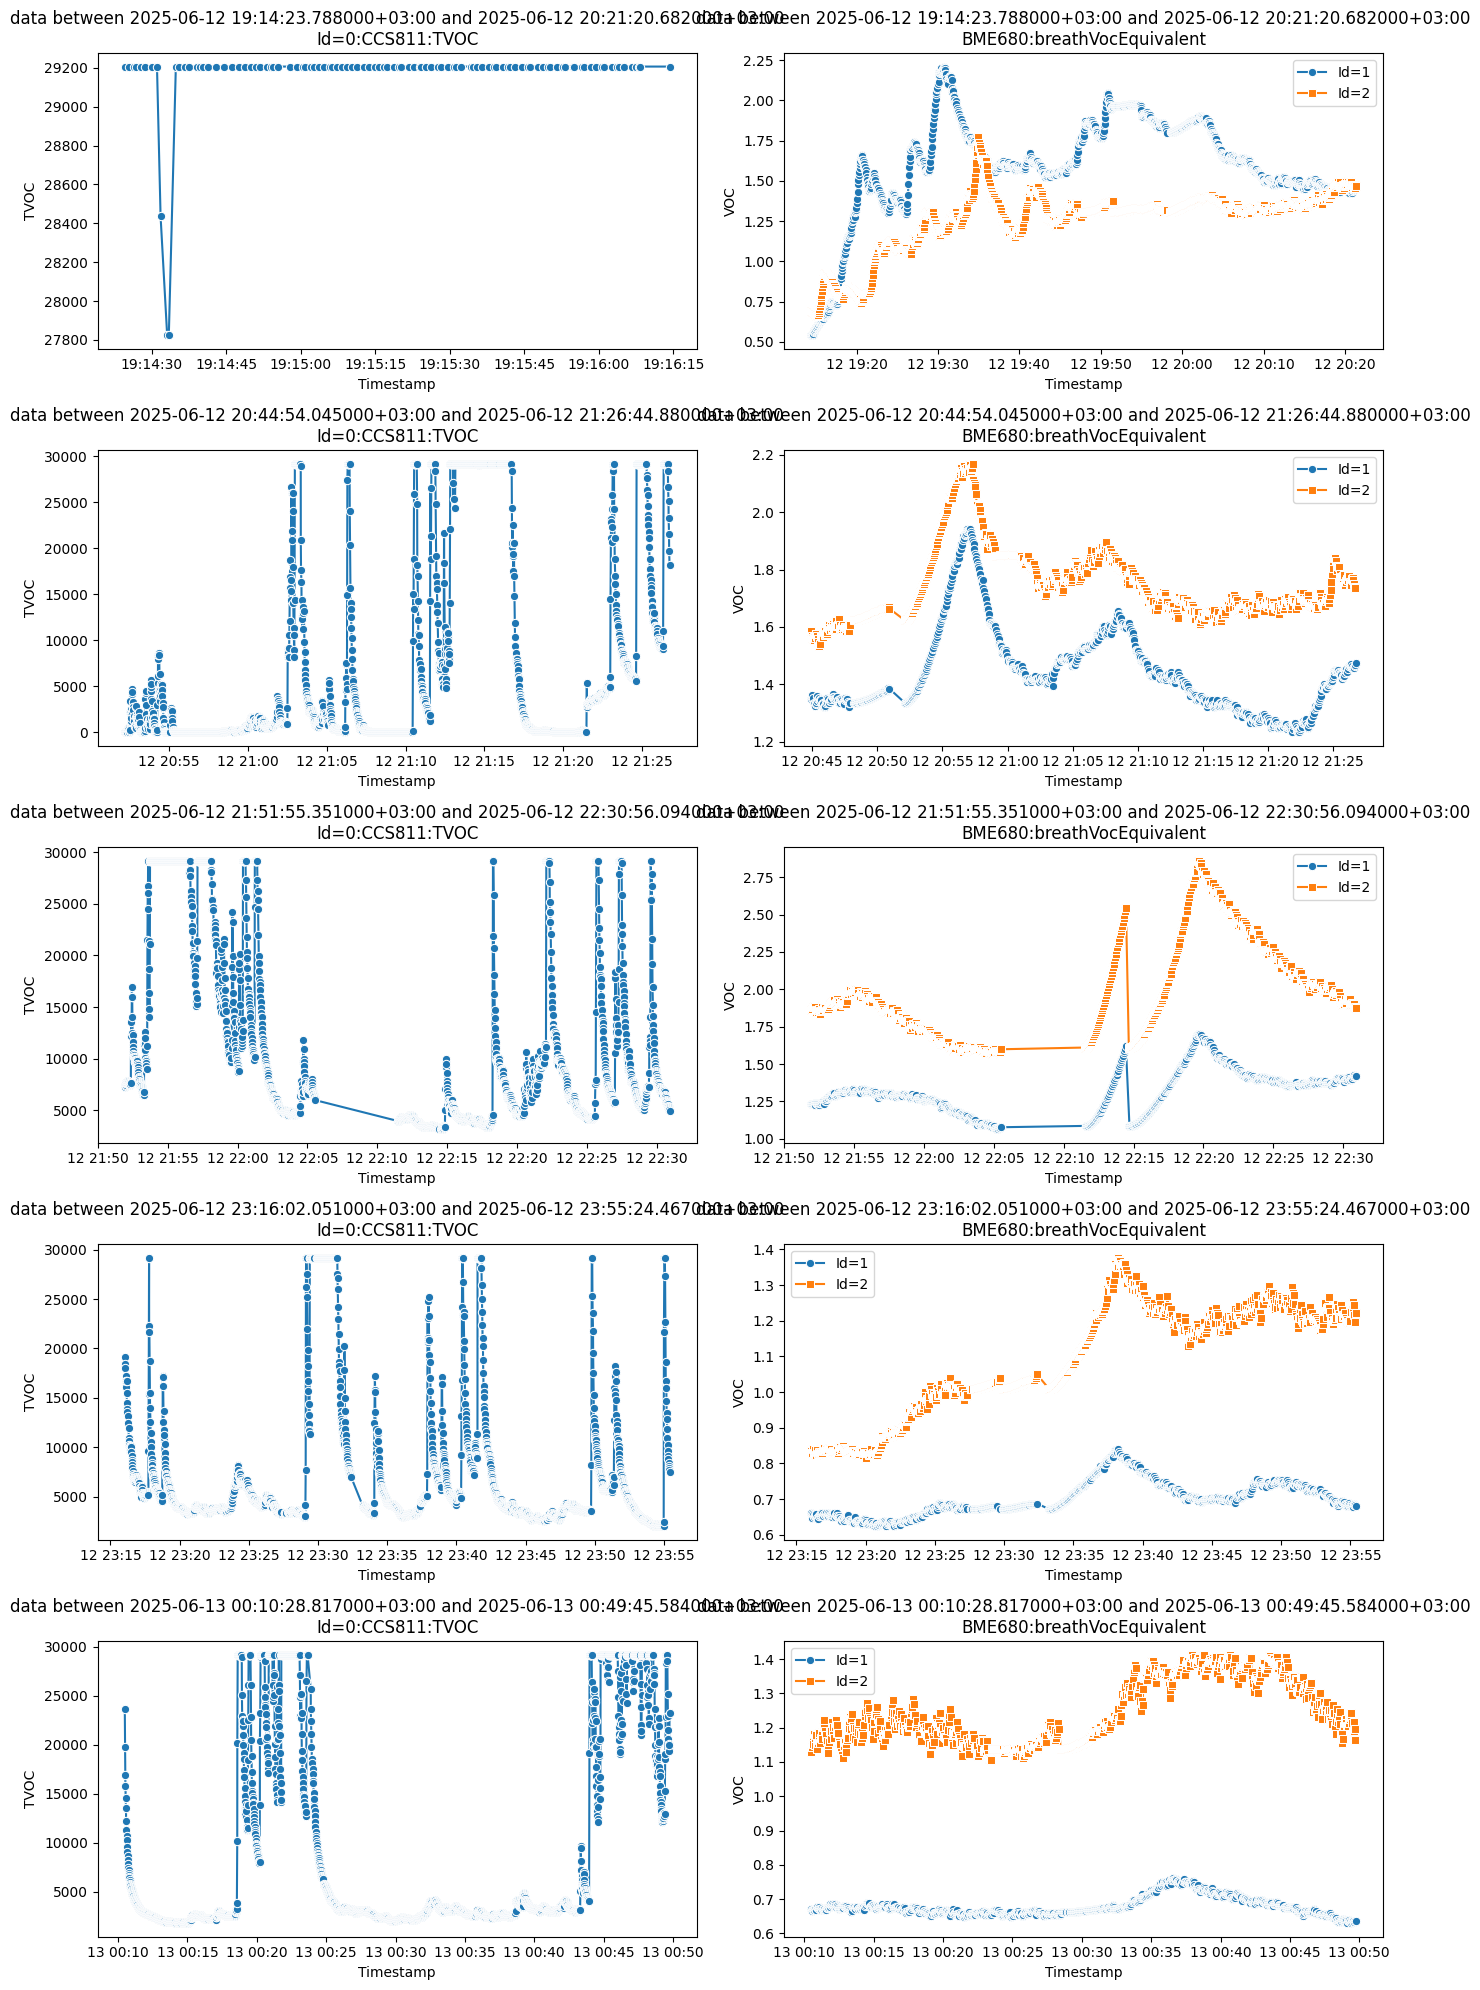

In [24]:
fig, axes = plt.subplots(num_experiments, 2, figsize=(14, 4 * num_experiments), sharex=False)

# Ensure axes is always a 2D array
if num_experiments == 1:
    axes = np.array([axes])

for idx, (start, end) in enumerate(experiment_periods):
    # Slice time series data between start and end
    df_range = df_timeSeriesDuringExperiments_final.loc[start:end]

    # LEFT PLOT: Id=0:CCS811:TVOC
    sns.lineplot(
        ax=axes[idx, 0],
        data=df_range,
        x=df_range.index,
        y='Id=0:CCS811:TVOC',
        marker='o'
    )
    axes[idx, 0].set_title(f"data between {start} and {end}\nId=0:CCS811:TVOC")
    axes[idx, 0].set_xlabel("Timestamp")
    axes[idx, 0].set_ylabel("TVOC")

    # RIGHT PLOT: Id=1 and Id=2 for BME680
    sns.lineplot(
        ax=axes[idx, 1],
        data=df_range,
        x=df_range.index,
        y='Id=1:BME680:breathVocEquivalent',
        label="Id=1",
        marker='o'
    )
    sns.lineplot(
        ax=axes[idx, 1],
        data=df_range,
        x=df_range.index,
        y='Id=2:BME680:breathVocEquivalent',
        label="Id=2",
        marker='s'
    )
    axes[idx, 1].set_title(f"data between {start} and {end}\nBME680:breathVocEquivalent")
    axes[idx, 1].set_xlabel("Timestamp")
    axes[idx, 1].set_ylabel("VOC")
    axes[idx, 1].legend()

# Adjust layout
plt.tight_layout()
plt.show()